In [3]:
from google.colab import files
uploaded = files.upload()

Saving blogs.csv to blogs.csv


In [8]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [5]:
data = pd.read_csv('/content/blogs.csv')

In [7]:
data.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [9]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [11]:
def clean_text(text):
    text = str(text).lower() # Lowercase
    text = text.translate(str.maketrans('', '', string.punctuation)) # Remove punctuation
    words = text.split() # Tokenize
    words = [w for w in words if w not in stop_words] # Remove stopwords
    return " ".join(words)

data['cleaned_text'] = data['Data'].apply(clean_text)

In [12]:
tfidf = TfidfVectorizer(max_features=5000) # Limit to top 5k words to save memory
X = tfidf.fit_transform(data['cleaned_text'])
y = data['Labels']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report\n", classification_report(y_test, y_pred))

Accuracy: 0.8225
Classification Report
                           precision    recall  f1-score   support

             alt.atheism       0.50      0.83      0.62        18
           comp.graphics       0.83      0.83      0.83        18
 comp.os.ms-windows.misc       0.86      0.82      0.84        22
comp.sys.ibm.pc.hardware       0.76      0.76      0.76        25
   comp.sys.mac.hardware       0.83      0.90      0.86        21
          comp.windows.x       0.91      0.84      0.88        25
            misc.forsale       0.78      0.78      0.78        18
               rec.autos       0.89      0.94      0.92        18
         rec.motorcycles       0.94      0.94      0.94        16
      rec.sport.baseball       0.77      0.94      0.85        18
        rec.sport.hockey       0.94      1.00      0.97        15
               sci.crypt       0.95      0.95      0.95        19
         sci.electronics       0.59      0.62      0.61        16
                 sci.med       0.88

In [16]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
def get_sentiment(text):
    analysis = TextBlob(str(text))
    # Polarity > 0 is Positive, < 0 is Negative, == 0 is Neutral
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

In [18]:
data['Sentiment'] = data['Data'].apply(get_sentiment)

/tmp/ipython-input-1598166839.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=data, palette='coolwarm')


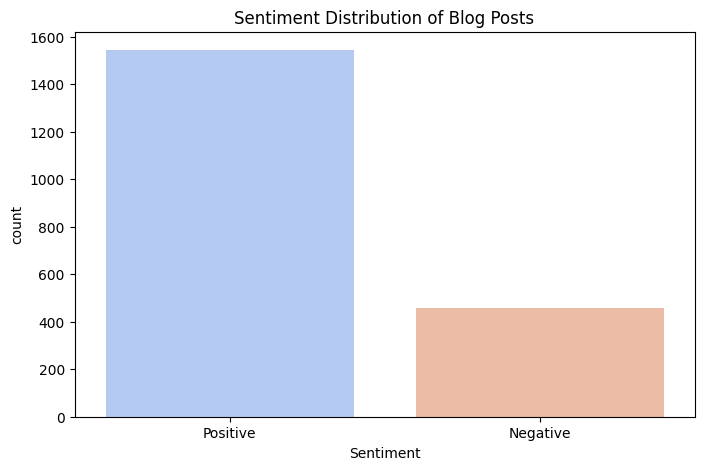

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Sentiment', data=data, palette='coolwarm')
plt.title('Sentiment Distribution of Blog Posts')
plt.show()

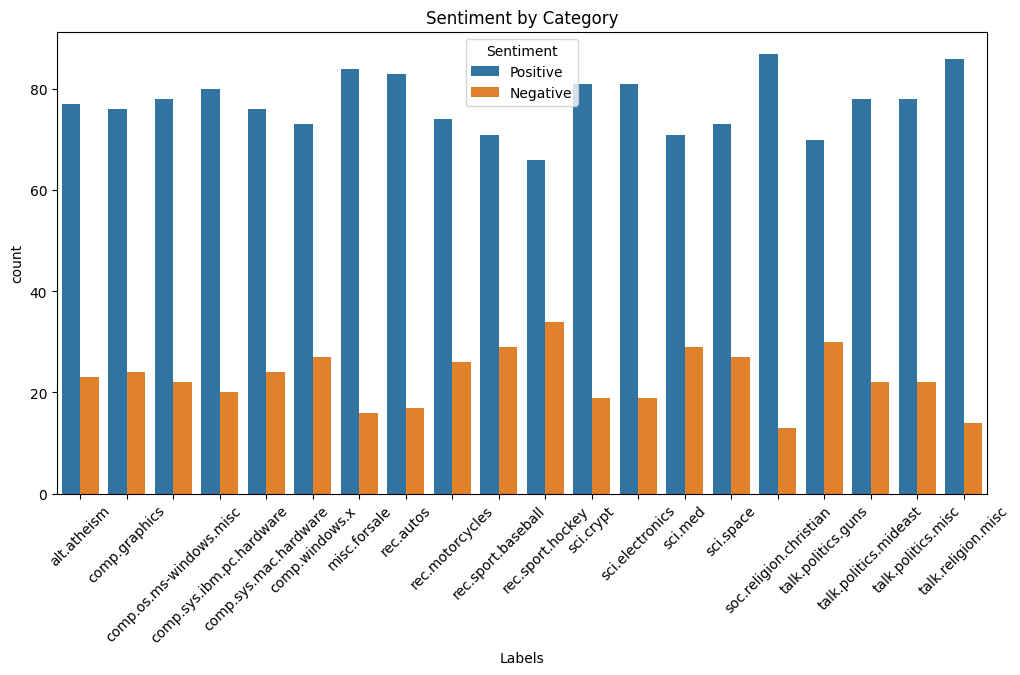

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Labels', hue='Sentiment', data=data)
plt.xticks(rotation=45)
plt.title('Sentiment by Category')
plt.show()